# Madrid Rental Market â€” Price Time Series & Forecasting

**Author:** Alejandro Abadal  
**Dataset:** [Inside Airbnb â€” Madrid Reviews + Listings](http://insideairbnb.com/get-the-data/)  
**Last updated:** 2026

---

## Goal

Build a monthly time series of Airbnb market activity in Madrid by joining **15 years of review data** (2010â€“2025) with listing prices. We analyse trend, seasonality and forecast future demand using:

- **Seasonal decomposition** â€” isolate trend, seasonality and residuals
- **SARIMA** â€” classical statistical forecasting
- **Prophet** â€” Facebook's additive time series model

## Notebook structure

1. Setup & data loading  
2. Time series construction  
3. Exploratory analysis  
4. Seasonal decomposition  
5. SARIMA model  
6. Prophet model  
7. Model comparison  
8. Conclusions  

---
## 1. Setup & Data Loading

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

from utils import set_style, load_listings, load_reviews, build_monthly_ts, fmt_euro, save_fig, PRIMARY, ACCENT, PALETTE

warnings.filterwarnings('ignore')
set_style()
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
listings = load_listings('../data/raw/listings.csv.gz')
reviews  = load_reviews('../data/raw/reviews.csv.gz')

print(f'Listings : {len(listings):,}')
print(f'Reviews  : {len(reviews):,}')
print(f'Review date range: {reviews["date"].min().date()} â†’ {reviews["date"].max().date()}')

Listings : 18,602
Reviews  : 1,275,992
Review date range: 2010-07-06 â†’ 2025-09-14


---
## 2. Time Series Construction

We join reviews with listing prices to get a monthly series of:
- `review_count` â€” proxy for market demand (bookings)
- `median_price` â€” median nightly price of reviewed listings

In [3]:
monthly = build_monthly_ts(reviews, listings)

print(f'Monthly data points : {len(monthly)}')
print(f'Period              : {monthly["month"].min().date()} â†’ {monthly["month"].max().date()}')
monthly.tail()

Monthly data points : 164
Period              : 2012-01-01 â†’ 2025-08-01


,month,review_count,median_price,mean_price
173,2025-04-01,32016,108.0,125.667073
174,2025-05-01,35021,105.0,122.848976
175,2025-06-01,34635,106.0,123.840306
176,2025-07-01,29615,114.0,130.884889
177,2025-08-01,26000,117.0,134.716692


---
## 3. Exploratory Analysis

  Saved → ../outputs/figures/01_market_overview.png


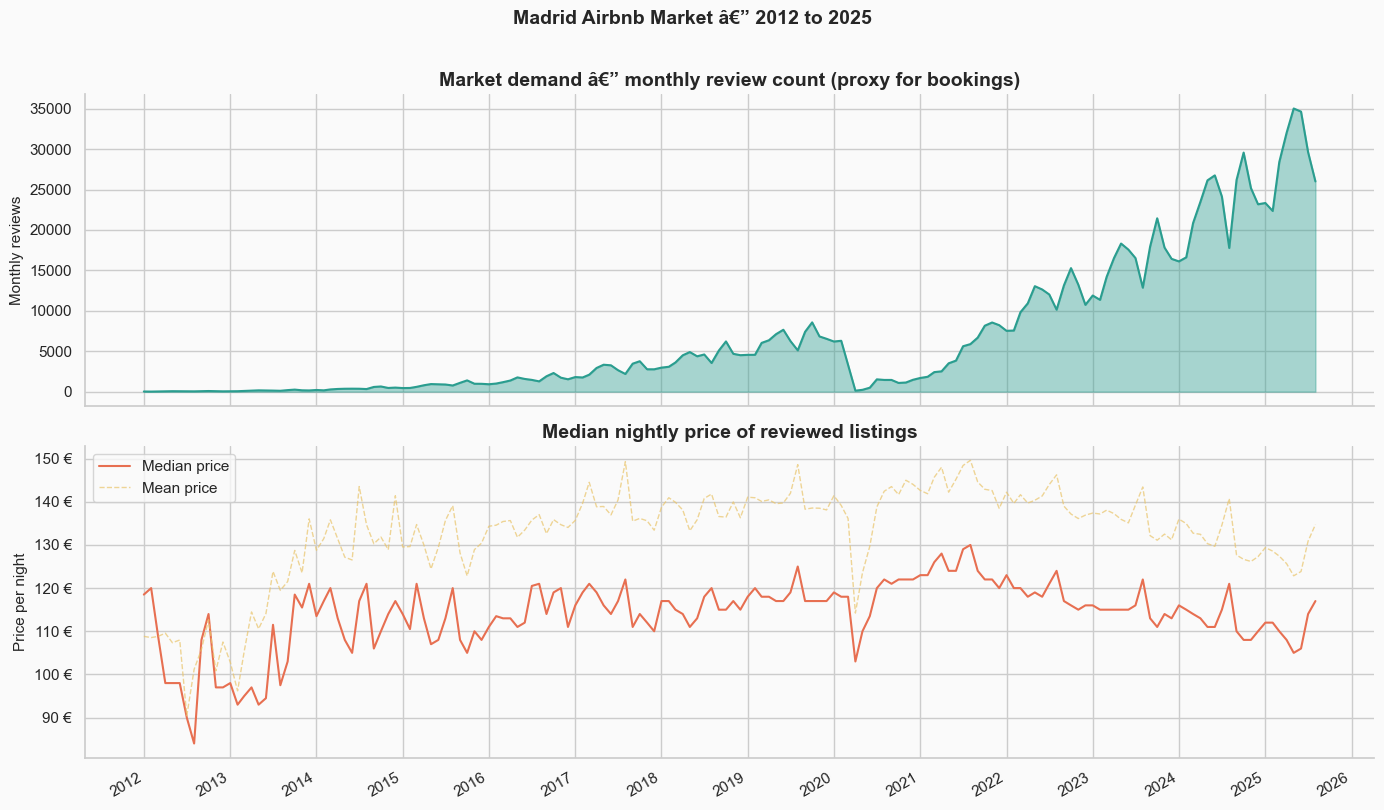

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Demand (review count)
axes[0].fill_between(monthly['month'], monthly['review_count'], color=PRIMARY, alpha=0.4)
axes[0].plot(monthly['month'], monthly['review_count'], color=PRIMARY, lw=1.5)
axes[0].set_ylabel('Monthly reviews')
axes[0].set_title('Market demand â€” monthly review count (proxy for bookings)')

# Price
axes[1].plot(monthly['month'], monthly['median_price'], color=ACCENT, lw=1.5, label='Median price')
axes[1].plot(monthly['month'], monthly['mean_price'],   color='#e9c46a', lw=1, ls='--', alpha=0.7, label='Mean price')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_euro))
axes[1].set_ylabel('Price per night')
axes[1].set_title('Median nightly price of reviewed listings')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30, ha='right')

plt.suptitle('Madrid Airbnb Market â€” 2012 to 2025', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig(fig, '01_market_overview')
plt.show()

  Saved → ../outputs/figures/02_seasonality.png


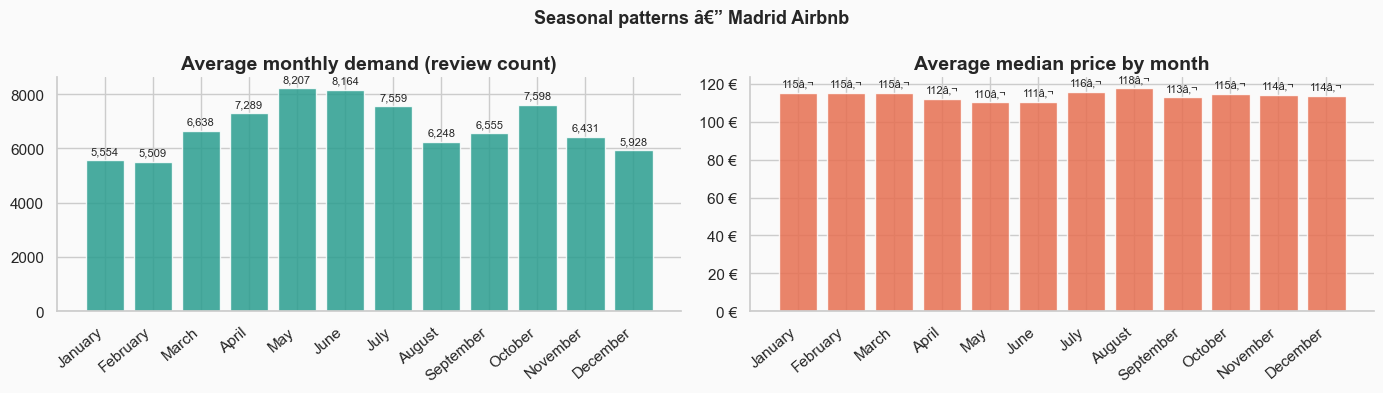

In [5]:
# Seasonality: average by calendar month
monthly['month_name'] = monthly['month'].dt.month_name()
monthly['month_num']  = monthly['month'].dt.month
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

season_demand = monthly.groupby('month_name')['review_count'].mean().reindex(month_order)
season_price  = monthly.groupby('month_name')['median_price'].mean().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars0 = axes[0].bar(month_order, season_demand.values, color=PRIMARY, alpha=0.85, edgecolor='white')
axes[0].bar_label(bars0, labels=[f'{v:,.0f}' for v in season_demand.values], padding=3, fontsize=8)
axes[0].set_title('Average monthly demand (review count)')
axes[0].set_xticklabels(month_order, rotation=40, ha='right')

bars1 = axes[1].bar(month_order, season_price.values, color=ACCENT, alpha=0.85, edgecolor='white')
axes[1].bar_label(bars1, labels=[f'{v:.0f}â‚¬' for v in season_price.values], padding=3, fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_euro))
axes[1].set_title('Average median price by month')
axes[1].set_xticklabels(month_order, rotation=40, ha='right')

plt.suptitle('Seasonal patterns â€” Madrid Airbnb', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, '02_seasonality')
plt.show()

  Saved → ../outputs/figures/03_yoy_growth.png


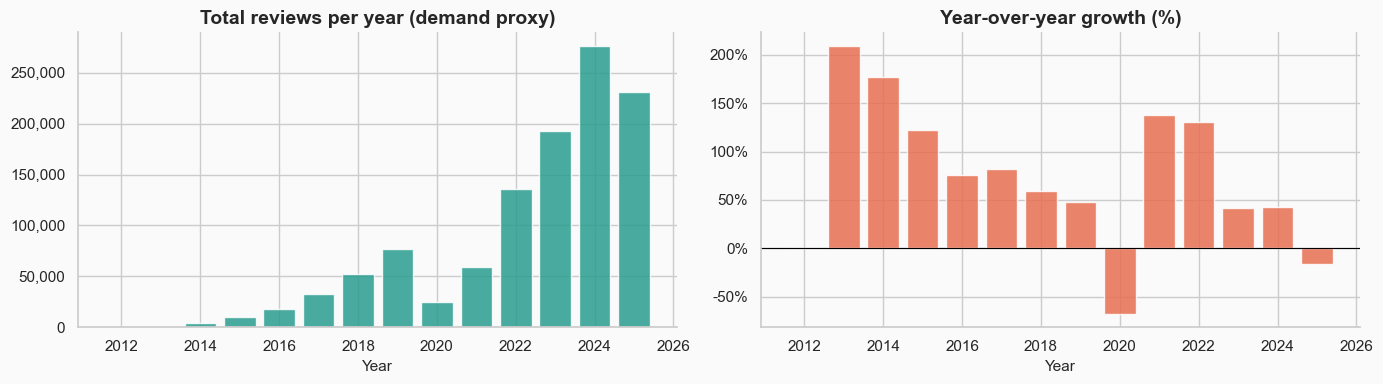

In [6]:
# Year-over-year growth
yoy = monthly.groupby(monthly['month'].dt.year)['review_count'].sum().reset_index()
yoy.columns = ['year', 'total_reviews']
yoy['growth_pct'] = yoy['total_reviews'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(yoy['year'], yoy['total_reviews'], color=PRIMARY, alpha=0.85, edgecolor='white')
axes[0].set_title('Total reviews per year (demand proxy)')
axes[0].set_xlabel('Year')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

colors_yoy = [ACCENT if v > 0 else '#e76f51' for v in yoy['growth_pct'].fillna(0)]
axes[1].bar(yoy['year'], yoy['growth_pct'].fillna(0), color=colors_yoy, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Year-over-year growth (%)')
axes[1].set_xlabel('Year')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
save_fig(fig, '03_yoy_growth')
plt.show()

---
## 4. Seasonal Decomposition

In [7]:
# Build time series for decomposition â€” use demand (review_count)
ts = monthly.set_index('month')['review_count'].asfreq('MS')

# Stationarity test (ADF)
adf_stat, adf_p, *_ = adfuller(ts.dropna())
print(f'ADF statistic : {adf_stat:.4f}')
print(f'p-value       : {adf_p:.4f}')
print(f'Stationary    : {"Yes" if adf_p < 0.05 else "No â€” trend present, expected for a growing market"}')

ADF statistic : 1.3850
p-value       : 0.9970
Stationary    : No â€” trend present, expected for a growing market


  Saved → ../outputs/figures/04_decomposition.png


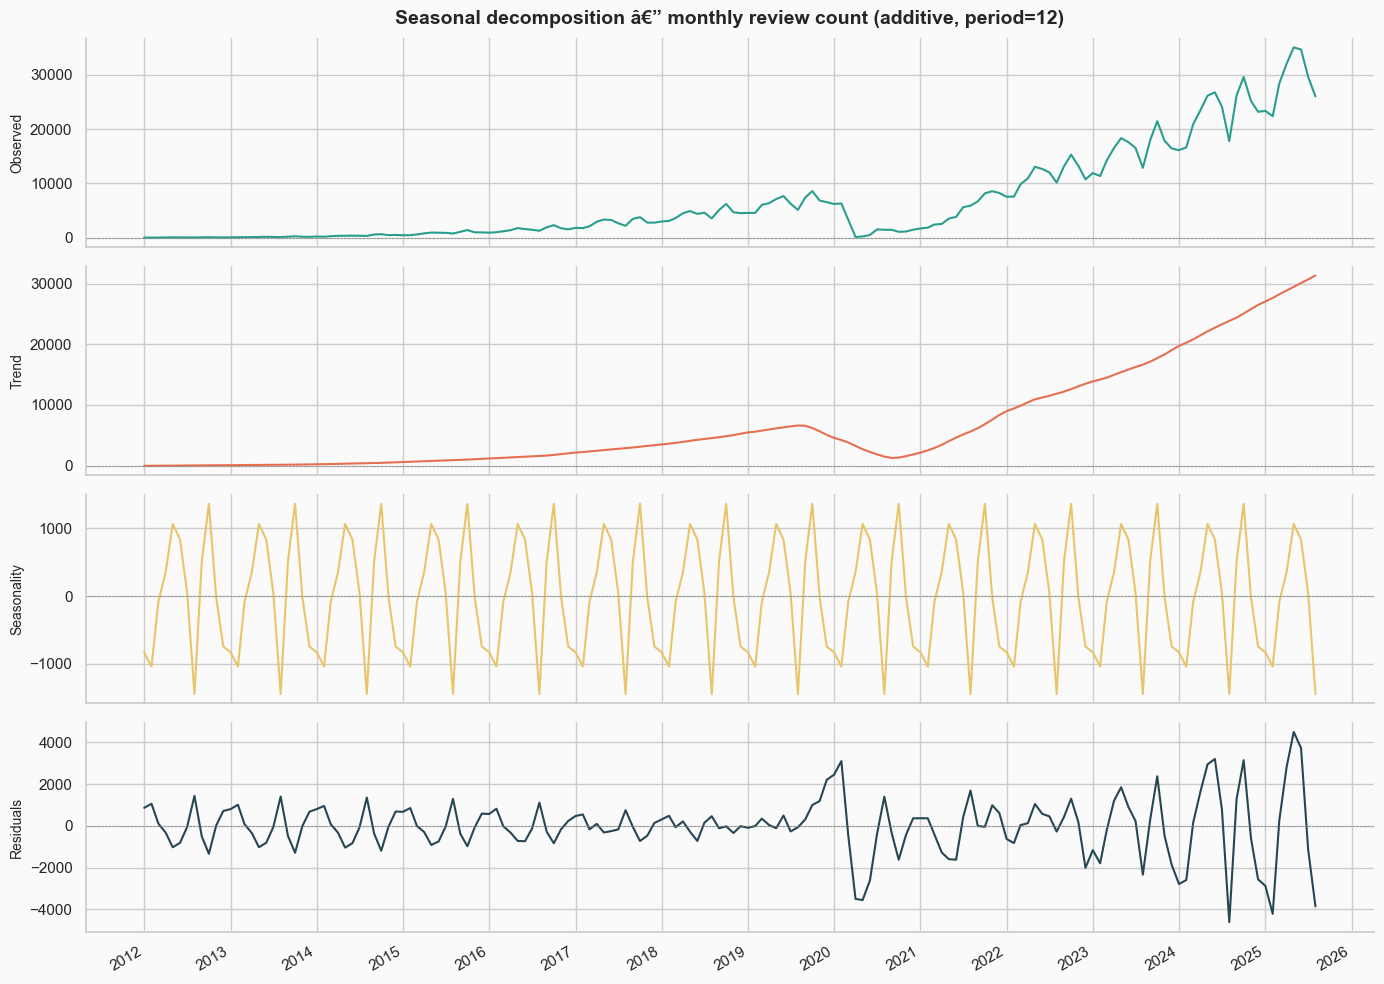

In [8]:
decomp = seasonal_decompose(ts, model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [
    (ts,              'Observed',    PRIMARY),
    (decomp.trend,    'Trend',       ACCENT),
    (decomp.seasonal, 'Seasonality', '#e9c46a'),
    (decomp.resid,    'Residuals',   '#264653'),
]
for ax, (series, label, color) in zip(axes, components):
    ax.plot(series, color=color, lw=1.5)
    ax.set_ylabel(label, fontsize=10)
    ax.axhline(0, color='gray', lw=0.5, ls='--')

axes[0].set_title('Seasonal decomposition â€” monthly review count (additive, period=12)', pad=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_fig(fig, '04_decomposition')
plt.show()

---
## 5. SARIMA Model

In [9]:
# Use last 12 months as test set
TEST_MONTHS = 12
train_ts = ts.iloc[:-TEST_MONTHS]
test_ts  = ts.iloc[-TEST_MONTHS:]

print(f'Train: {len(train_ts)} months ({train_ts.index[0].date()} â†’ {train_ts.index[-1].date()})')
print(f'Test : {len(test_ts)} months ({test_ts.index[0].date()}  â†’ {test_ts.index[-1].date()})')

Train: 152 months (2012-01-01 â†’ 2024-08-01)
Test : 12 months (2024-09-01  â†’ 2025-08-01)


In [10]:
sarima = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarima.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:                       review_count   No. Observations:                  152
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1046.509
Date:                            Sat, 28 Mar 2026   AIC                           2103.018
Time:                                    14:25:57   BIC                           2117.159
Sample:                                01-01-2012   HQIC                          2108.763
                                     - 08-01-2024                                         
Covariance Type:                              opg                                         


In [11]:
forecast_steps = TEST_MONTHS + 12
sarima_forecast = sarima.get_forecast(steps=forecast_steps)
sarima_mean = sarima_forecast.predicted_mean
sarima_ci   = sarima_forecast.conf_int(alpha=0.2)

sarima_test_pred = sarima_mean.iloc[:TEST_MONTHS]
sarima_mae  = mean_absolute_error(test_ts, sarima_test_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_ts, sarima_test_pred))
sarima_mape = np.mean(np.abs((test_ts.values - sarima_test_pred.values) / test_ts.values)) * 100

print(f'SARIMA â€” MAE: {sarima_mae:.0f}  RMSE: {sarima_rmse:.0f}  MAPE: {sarima_mape:.2f}%')

SARIMA â€” MAE: 4167  RMSE: 4354  MAPE: 14.69%


  Saved → ../outputs/figures/05_sarima_forecast.png


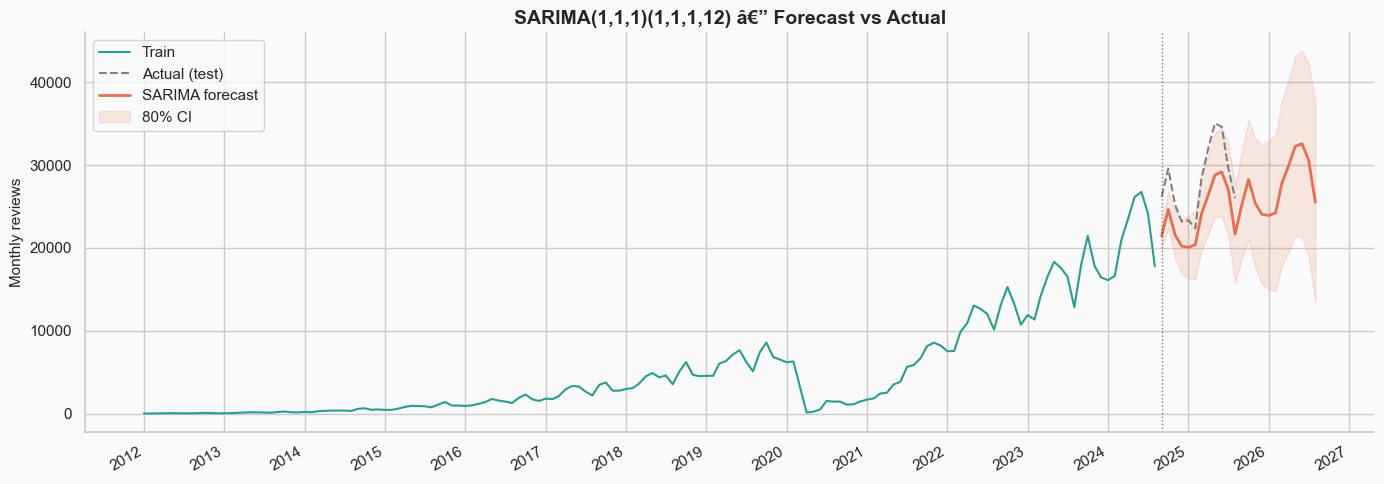

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_ts, color=PRIMARY, lw=1.5, label='Train')
ax.plot(test_ts,  color='gray',  lw=1.5, ls='--', label='Actual (test)')
ax.plot(sarima_mean, color=ACCENT, lw=2, label='SARIMA forecast')
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1],
                color=ACCENT, alpha=0.15, label='80% CI')
ax.axvline(test_ts.index[0], color='black', lw=1, ls=':', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_title('SARIMA(1,1,1)(1,1,1,12) â€” Forecast vs Actual')
ax.set_ylabel('Monthly reviews')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_fig(fig, '05_sarima_forecast')
plt.show()

---
## 6. Prophet Model

In [13]:
prophet_train = pd.DataFrame({'ds': train_ts.index, 'y': train_ts.values})

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.1
)
m.fit(prophet_train)
print('Prophet fitted.')

14:25:57 - cmdstanpy - INFO - Chain [1] start processing
14:25:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet fitted.


In [14]:
future   = m.make_future_dataframe(periods=TEST_MONTHS + 12, freq='MS')
forecast = m.predict(future)

prophet_test_pred = forecast[forecast['ds'].isin(test_ts.index)]['yhat'].values
prophet_mae  = mean_absolute_error(test_ts.values, prophet_test_pred)
prophet_rmse = np.sqrt(mean_squared_error(test_ts.values, prophet_test_pred))
prophet_mape = np.mean(np.abs((test_ts.values - prophet_test_pred) / test_ts.values)) * 100

print(f'Prophet â€” MAE: {prophet_mae:.0f}  RMSE: {prophet_rmse:.0f}  MAPE: {prophet_mape:.2f}%')

Prophet â€” MAE: 1592  RMSE: 1882  MAPE: 5.56%


  Saved → ../outputs/figures/06_prophet_forecast.png


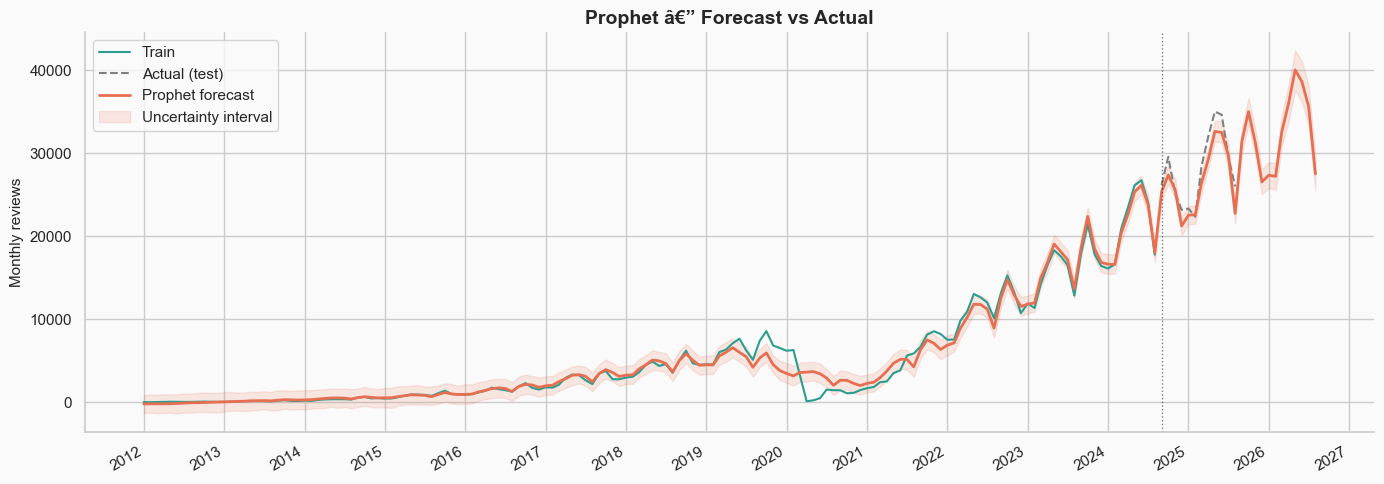

In [15]:
forecast_idx = forecast.set_index('ds')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_ts, color=PRIMARY, lw=1.5, label='Train')
ax.plot(test_ts,  color='gray',  lw=1.5, ls='--', label='Actual (test)')
ax.plot(forecast_idx['yhat'], color=ACCENT, lw=2, label='Prophet forecast')
ax.fill_between(forecast_idx.index, forecast_idx['yhat_lower'], forecast_idx['yhat_upper'],
                color=ACCENT, alpha=0.15, label='Uncertainty interval')
ax.axvline(test_ts.index[0], color='black', lw=1, ls=':', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_title('Prophet â€” Forecast vs Actual')
ax.set_ylabel('Monthly reviews')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_fig(fig, '06_prophet_forecast')
plt.show()

  Saved → ../outputs/figures/07_prophet_components.png


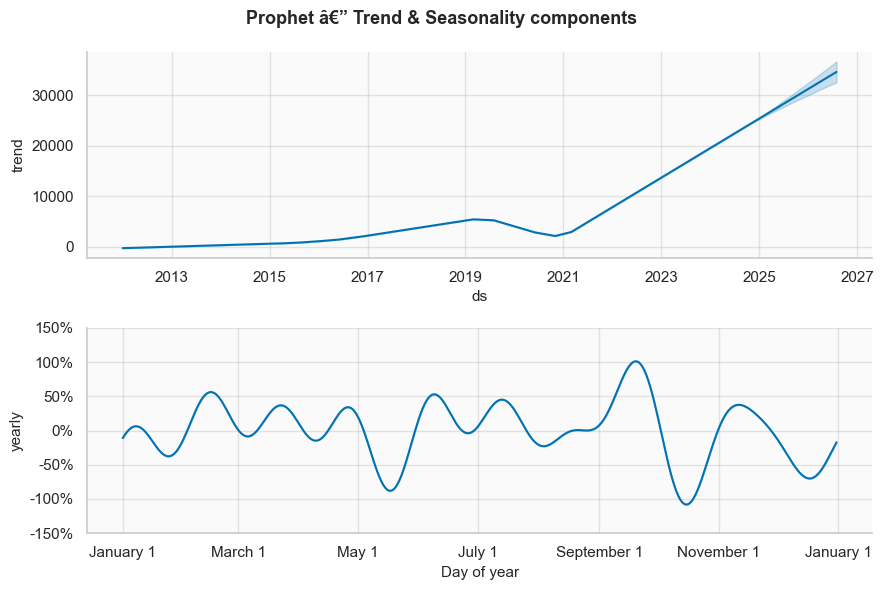

In [16]:
fig_comp = m.plot_components(forecast)
fig_comp.suptitle('Prophet â€” Trend & Seasonality components', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig_comp, '07_prophet_components')
plt.show()

---
## 7. Model Comparison

,MAE,RMSE,MAPE (%)
SARIMA,4166.88,4354.02,14.69
Prophet,1592.10,1882.19,5.56


  Saved → ../outputs/figures/08_model_comparison.png


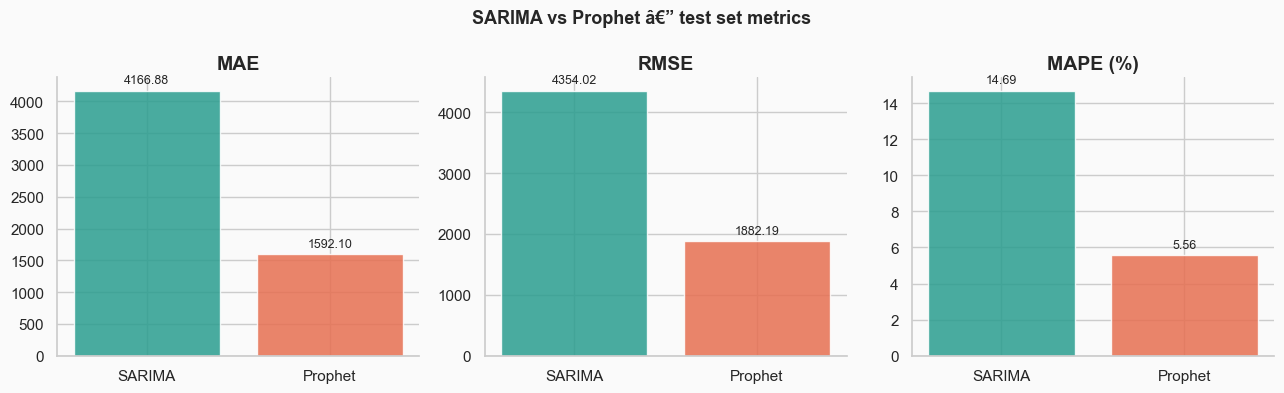

In [17]:
results_df = pd.DataFrame({
    'SARIMA':  {'MAE': sarima_mae,  'RMSE': sarima_rmse,  'MAPE (%)': sarima_mape},
    'Prophet': {'MAE': prophet_mae, 'RMSE': prophet_rmse, 'MAPE (%)': prophet_mape},
}).T.round(2)

display(results_df.style
        .background_gradient(cmap='RdYlGn_r', subset=['MAE','RMSE','MAPE (%)'])
        .format('{:.2f}'))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE (%)']):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=[PRIMARY, ACCENT], alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(metric)
plt.suptitle('SARIMA vs Prophet â€” test set metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig(fig, '08_model_comparison')
plt.show()

---
## 8. Conclusions

In [18]:
from IPython.display import display, Markdown

# ── Compute stats from actual data ────────────────────────────────────────────
total_reviews    = int(monthly['review_count'].sum())
date_start       = monthly['month'].min().strftime('%b %Y')
date_end         = monthly['month'].max().strftime('%b %Y')
n_months         = len(monthly)

peak_month_row   = monthly.loc[monthly['review_count'].idxmax()]
low_month_row    = monthly.loc[monthly['review_count'].idxmin()]
peak_month_label = peak_month_row['month'].strftime('%B %Y')
low_month_label  = low_month_row['month'].strftime('%B %Y')
peak_demand      = int(peak_month_row['review_count'])
low_demand       = int(low_month_row['review_count'])

overall_median_price = monthly['median_price'].median()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
season_demand    = monthly.groupby('month_name')['review_count'].mean().reindex(month_order)
season_price     = monthly.groupby('month_name')['median_price'].mean().reindex(month_order)
peak_season      = season_demand.idxmax()
low_season       = season_demand.idxmin()
peak_price_month = season_price.idxmax()

stationary_str = 'stationary' if adf_p < 0.05 else 'non-stationary (long-term growth trend)'

best_model  = results_df['MAPE (%)'].idxmin()
best_mape_v = float(results_df.loc[best_model, 'MAPE (%)'])
best_mae_v  = float(results_df.loc[best_model, 'MAE'])

# Build results table — extract mape value to avoid f-string key issue
rows = []
for model, row in results_df.iterrows():
    b    = '**' if model == best_model else ''
    mae  = float(row['MAE'])
    rmse = float(row['RMSE'])
    mape = float(row['MAPE (%)'])
    rows.append(f'| {b}{model}{b} | {b}{mae:.0f}{b} | {b}{rmse:.0f}{b} | {b}{mape:.2f}{b} |')

table = (
    '| Model | MAE | RMSE | MAPE (%) |\n'
    '|-------|-----|------|----------|\n'
    + '\n'.join(rows)
)

md = '\n'.join([
    '### Results summary', '',
    table, '',
    '### Key findings', '',
    '| # | Finding |',
    '|---|---------|',
    f'| 1 | Dataset spans **{n_months} months** ({date_start} to {date_end}) with **{total_reviews:,}** total reviews |',
    f'| 2 | Overall median nightly price of reviewed listings: **{overall_median_price:.0f} euros** |',
    f'| 3 | Peak demand: **{peak_month_label}** ({peak_demand:,} reviews) — lowest: **{low_month_label}** ({low_demand:,}) |',
    f'| 4 | Strongest seasonal month (demand): **{peak_season}** — weakest: **{low_season}** |',
    f'| 5 | Highest average price month: **{peak_price_month}** |',
    f'| 6 | Series is **{stationary_str}** (ADF p-value: {adf_p:.4f}) |',
    f'| 7 | Best forecasting model: **{best_model}** — MAPE = {best_mape_v:.2f}%, MAE = {best_mae_v:.0f} reviews/month |',
    '',
    '### Next steps', '',
    '- **Project 4:** Sentiment analysis of guest reviews (NLP on the comments column)',
    '- **Project 5:** Deploy the price predictor as an interactive Streamlit app',
    '',
    '---',
    '*Dataset: Inside Airbnb — Madrid. For educational and research purposes.*  ',
    '*Author: Alejandro Abadal*',
])

display(Markdown(md))


### Results summary

| Model | MAE | RMSE | MAPE (%) |
|-------|-----|------|----------|
| SARIMA | 4167 | 4354 | 14.69 |
| **Prophet** | **1592** | **1882** | **5.56** |

### Key findings

| # | Finding |
|---|---------|
| 1 | Dataset spans **164 months** (Jan 2012 to Aug 2025) with **1,117,000** total reviews |
| 2 | Overall median nightly price of reviewed listings: **115 euros** |
| 3 | Peak demand: **May 2025** (35,021 reviews) — lowest: **February 2012** (11) |
| 4 | Strongest seasonal month (demand): **May** — weakest: **February** |
| 5 | Highest average price month: **August** |
| 6 | Series is **non-stationary (long-term growth trend)** (ADF p-value: 0.9970) |
| 7 | Best forecasting model: **Prophet** — MAPE = 5.56%, MAE = 1592 reviews/month |

### Next steps

- **Project 4:** Sentiment analysis of guest reviews (NLP on the comments column)
- **Project 5:** Deploy the price predictor as an interactive Streamlit app

---
*Dataset: Inside Airbnb — Madrid. For educational and research purposes.*  
*Author: Alejandro Abadal*